In [1]:
#load packages needed
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
import pandas as pd
import seaborn as sns

#go to working directory
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')
data = loadmat('Clinical_Outcomes_Workspace.mat') #Load matlab workspace for importing variables 

# See what variables are inside
print(data.keys())

/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


dict_keys(['__header__', '__version__', '__globals__', 'Adjustment_Disorder', 'Alcohol_Related_Disorder', 'Amnestic_disorders', 'Amphetamine_Related_Disorder', 'Anorexia_Nervosa', 'Antisocial_Personality_Disorder', 'Anxiety_Disorder', 'Aspergers', 'Attention_Deficit_Disruptive_Behavior', 'Attention_Deficit_hyperactivity', 'Autism', 'Autonomic_HotCold_Flashes', 'Avoidant_Personality_Disorder', 'BSC_100_Having_dark_thoughts_ones_that_may_involve_suicidal_or_', 'BSC_101_Experiencing_periods_of_forgetfulness_or_memory_problem', 'BSC_10_Having_poor_planning_skills', 'BSC_11_Lacking_clear_goals_or_forward_thinking', 'BSC_12_Having_difficulty_expressing_feelings', 'BSC_13_Having_difficulty_expressing_empathy_for_others', 'BSC_14_Experiencing_excessive_daydreaming', 'BSC_15_Feeling_bored', 'BSC_16_Feeling_apathetic_or_unmotivated', 'BSC_17_Feeling_tired_sluggish_or_slow_moving', 'BSC_18_Feeling_spacey_or_in_a_fog', 'BSC_19_Feeling_fidgety_restless_or_trouble_sitting_still', 'BSC_1_Failing_to_g

In [2]:
#extract clinical variables needed for analysis 
BSC_78_Having_low_motivation = data['BSC_78_Having_low_motivation'].flatten()
BSC_87_Being_sensitive_to_criticism = data['BSC_87_Being_sensitive_to_criticism'].flatten()
BSC_12_Having_difficulty_expressing_feelings = data['BSC_12_Having_difficulty_expressing_feelings'].flatten()
BSC_45_Tending_to_predict_fear = data['BSC_45_Tending_to_predict_fear'].flatten()
BSC_70_Feeling_nausea_or_having_an_upset_stomach = data['BSC_70_Feeling_nausea_or_having_an_upset_stomach'].flatten()
BSC_59_Having_lowered_interest_in_things_that_are_usually_consi = data['BSC_59_Having_lowered_interest_in_things_that_are_usually_consi'].flatten()
BSC_5_Having_poor_organization_for_time_or_space_such_as_a_back = data['BSC_5_Having_poor_organization_for_time_or_space_such_as_a_back'].flatten()
BSC_6_Avoiding_disliking_or_being_reluctant_to_engage_in_tasks_= data['BSC_6_Avoiding_disliking_or_being_reluctant_to_engage_in_tasks_'].flatten()
BSC_73_Having_a_fear_of_dying_or_doing_something_crazy = data['BSC_73_Having_a_fear_of_dying_or_doing_something_crazy'].flatten()
GSC_A_18_Experiencing_panic_attacks_which_are_periods_of_intens = data['GSC_A_18_Experiencing_panic_attacks_which_are_periods_of_intens'].flatten()
GSC_A_35_Having_recurrent_bothersome_thoughts_ideas_or_images_t = data['GSC_A_35_Having_recurrent_bothersome_thoughts_ideas_or_images_t'].flatten()
GSC_A_8_Having_feelings_of_worthlessness_helplessness_hopelessn = data['GSC_A_8_Having_feelings_of_worthlessness_helplessness_hopelessn'].flatten()
GSC_A_98_Hearing_voices_or_sounds_that_are_not_real = data['GSC_A_98_Hearing_voices_or_sounds_that_are_not_real'].flatten()
GSC_A_99_Experiencing_periods_of_time_where_your_thoughts_or_sp = data['GSC_A_99_Experiencing_periods_of_time_where_your_thoughts_or_sp'].flatten()

#diagnostic criteria groups definitions
Anxiety_Disorder = data['Anxiety_Disorder'].flatten()
Attention_Deficit_hyperactivity = data['Attention_Deficit_hyperactivity'].flatten()
Autism = data['Autism'].flatten()
Bipolar_Disorder = data['Bipolar_Disorder'].flatten()
Depressive_Disorder = data['Depressive_Disorder'].flatten()
Schizoid_Personality_Disorder = data['Schizoid_Personality_Disorder'].flatten()
Schizotypal_personality_disorder = data['Schizotypal_personality_disorder'].flatten()
age = data['age'].flatten()

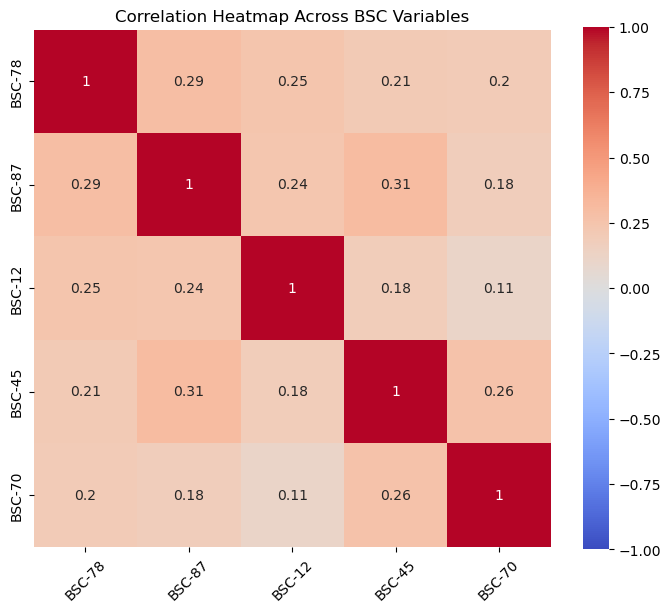

In [3]:

# ---------------------------------------------------------
# Combine variables into a DataFrame
# ---------------------------------------------------------
df = pd.DataFrame({
    'BSC-78': BSC_78_Having_low_motivation.flatten(),
    'BSC-87': BSC_87_Being_sensitive_to_criticism.flatten(),
    'BSC-12': BSC_12_Having_difficulty_expressing_feelings.flatten(),
    'BSC-45': BSC_45_Tending_to_predict_fear.flatten(),
    'BSC-70': BSC_70_Feeling_nausea_or_having_an_upset_stomach.flatten()
})

# ---------------------------------------------------------
# Compute correlation matrix
# ---------------------------------------------------------
R = df.corr()

# ---------------------------------------------------------
# Plot heatmap
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
sns.heatmap(R, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)

plt.title('Correlation Heatmap Across BSC Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


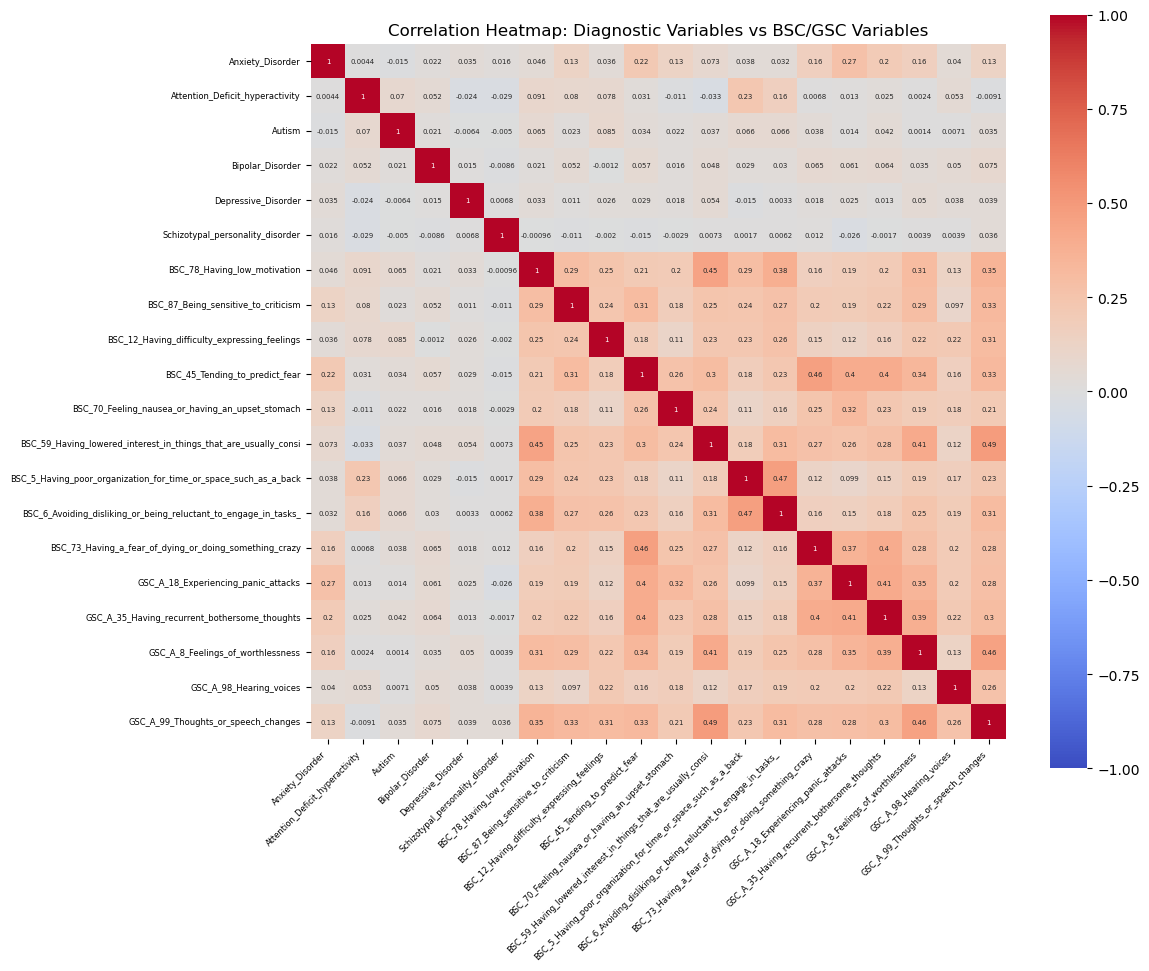

In [5]:
# do transdiagnostic correlations with BSC + GSC variables

# ---------------------------------------------------------
# Build DataFrame
# ---------------------------------------------------------
df = pd.DataFrame({
    # Diagnostic variables
    'Anxiety_Disorder': Anxiety_Disorder.flatten(),
    'Attention_Deficit_hyperactivity': Attention_Deficit_hyperactivity.flatten(),
    'Autism': Autism.flatten(),
    'Bipolar_Disorder': Bipolar_Disorder.flatten(),
    'Depressive_Disorder': Depressive_Disorder.flatten(),
    'Schizotypal_personality_disorder': Schizotypal_personality_disorder.flatten(),

    # BSC variables
    'BSC_78_Having_low_motivation': data['BSC_78_Having_low_motivation'].flatten(),
    'BSC_87_Being_sensitive_to_criticism': data['BSC_87_Being_sensitive_to_criticism'].flatten(),
    'BSC_12_Having_difficulty_expressing_feelings': data['BSC_12_Having_difficulty_expressing_feelings'].flatten(),
    'BSC_45_Tending_to_predict_fear': data['BSC_45_Tending_to_predict_fear'].flatten(),
    'BSC_70_Feeling_nausea_or_having_an_upset_stomach': data['BSC_70_Feeling_nausea_or_having_an_upset_stomach'].flatten(),
    'BSC_59_Having_lowered_interest_in_things_that_are_usually_consi': data['BSC_59_Having_lowered_interest_in_things_that_are_usually_consi'].flatten(),
    'BSC_5_Having_poor_organization_for_time_or_space_such_as_a_back': data['BSC_5_Having_poor_organization_for_time_or_space_such_as_a_back'].flatten(),
    'BSC_6_Avoiding_disliking_or_being_reluctant_to_engage_in_tasks_': data['BSC_6_Avoiding_disliking_or_being_reluctant_to_engage_in_tasks_'].flatten(),
    'BSC_73_Having_a_fear_of_dying_or_doing_something_crazy': data['BSC_73_Having_a_fear_of_dying_or_doing_something_crazy'].flatten(),

    # GSC variables
    'GSC_A_18_Experiencing_panic_attacks': data['GSC_A_18_Experiencing_panic_attacks_which_are_periods_of_intens'].flatten(),
    'GSC_A_35_Having_recurrent_bothersome_thoughts': data['GSC_A_35_Having_recurrent_bothersome_thoughts_ideas_or_images_t'].flatten(),
    'GSC_A_8_Feelings_of_worthlessness': data['GSC_A_8_Having_feelings_of_worthlessness_helplessness_hopelessn'].flatten(),
    'GSC_A_98_Hearing_voices': data['GSC_A_98_Hearing_voices_or_sounds_that_are_not_real'].flatten(),
    'GSC_A_99_Thoughts_or_speech_changes': data['GSC_A_99_Experiencing_periods_of_time_where_your_thoughts_or_sp'].flatten()
})

# ---------------------------------------------------------
# Correlation matrix
# ---------------------------------------------------------
R = df.corr()

# ---------------------------------------------------------
# Plot heatmap
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    R,
    annot=True,
    annot_kws={'size': 5},
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True
)

plt.title('Correlation Heatmap: Diagnostic Variables vs BSC/GSC Variables', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()


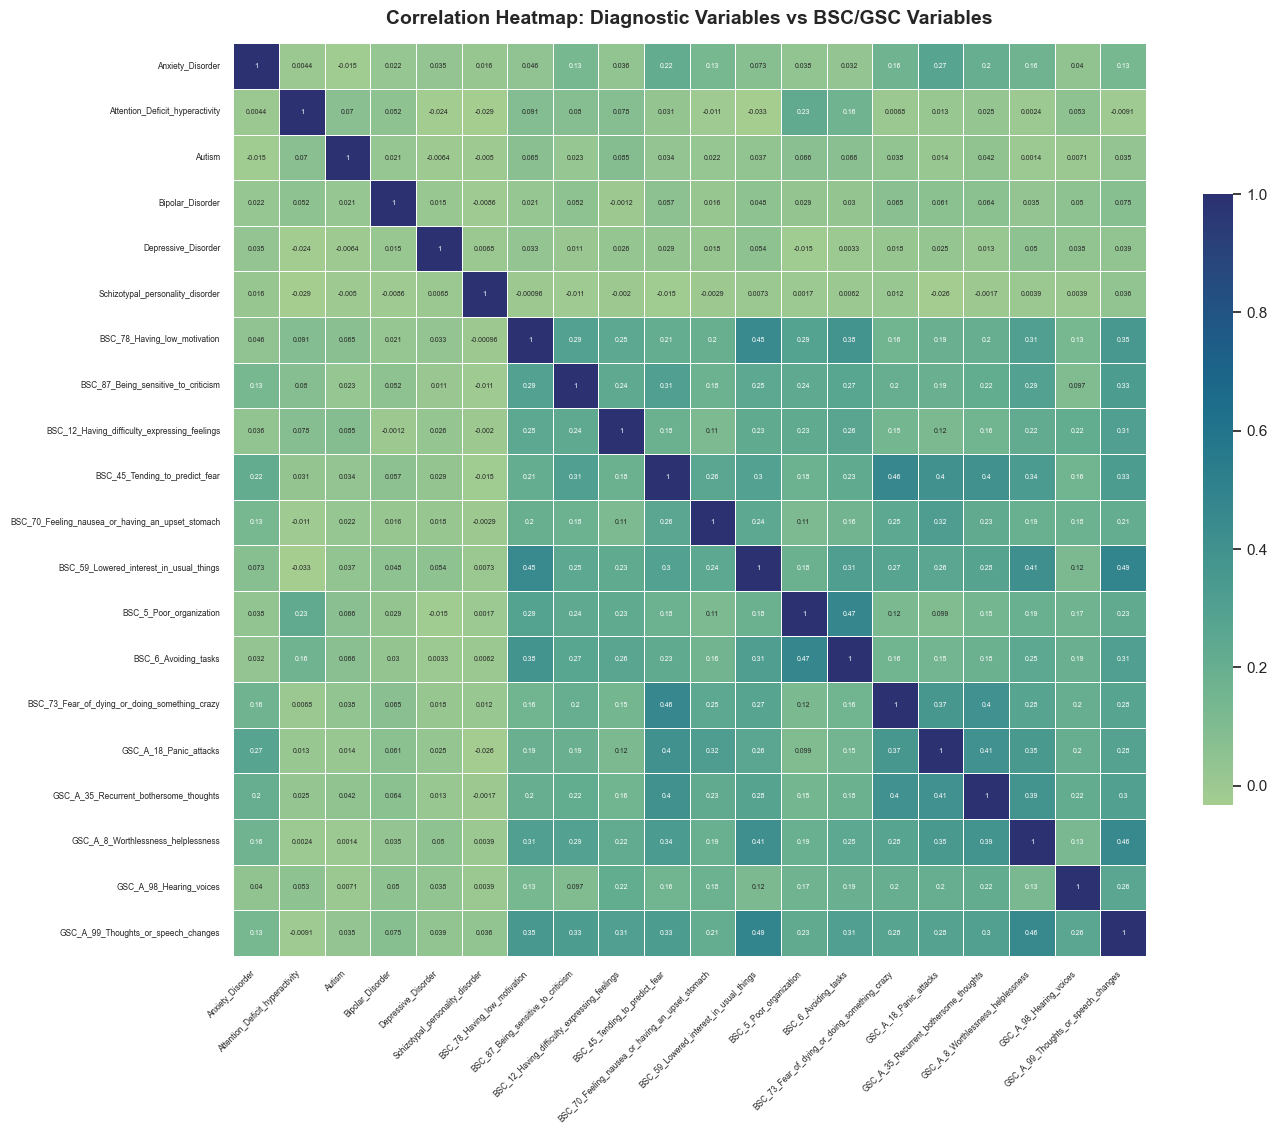

In [6]:
# another correlation plot
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# Build DataFrame
# ---------------------------------------------------------
df = pd.DataFrame({
    # Diagnostic variables
    'Anxiety_Disorder': Anxiety_Disorder.flatten(),
    'Attention_Deficit_hyperactivity': Attention_Deficit_hyperactivity.flatten(),
    'Autism': Autism.flatten(),
    'Bipolar_Disorder': Bipolar_Disorder.flatten(),
    'Depressive_Disorder': Depressive_Disorder.flatten(),
    'Schizotypal_personality_disorder': Schizotypal_personality_disorder.flatten(),

    # BSC variables
    'BSC_78_Having_low_motivation': data['BSC_78_Having_low_motivation'].flatten(),
    'BSC_87_Being_sensitive_to_criticism': data['BSC_87_Being_sensitive_to_criticism'].flatten(),
    'BSC_12_Having_difficulty_expressing_feelings': data['BSC_12_Having_difficulty_expressing_feelings'].flatten(),
    'BSC_45_Tending_to_predict_fear': data['BSC_45_Tending_to_predict_fear'].flatten(),
    'BSC_70_Feeling_nausea_or_having_an_upset_stomach': data['BSC_70_Feeling_nausea_or_having_an_upset_stomach'].flatten(),
    'BSC_59_Lowered_interest_in_usual_things': data['BSC_59_Having_lowered_interest_in_things_that_are_usually_consi'].flatten(),
    'BSC_5_Poor_organization': data['BSC_5_Having_poor_organization_for_time_or_space_such_as_a_back'].flatten(),
    'BSC_6_Avoiding_tasks': data['BSC_6_Avoiding_disliking_or_being_reluctant_to_engage_in_tasks_'].flatten(),
    'BSC_73_Fear_of_dying_or_doing_something_crazy': data['BSC_73_Having_a_fear_of_dying_or_doing_something_crazy'].flatten(),

    # GSC variables
    'GSC_A_18_Panic_attacks': data['GSC_A_18_Experiencing_panic_attacks_which_are_periods_of_intens'].flatten(),
    'GSC_A_35_Recurrent_bothersome_thoughts': data['GSC_A_35_Having_recurrent_bothersome_thoughts_ideas_or_images_t'].flatten(),
    'GSC_A_8_Worthlessness_helplessness': data['GSC_A_8_Having_feelings_of_worthlessness_helplessness_hopelessn'].flatten(),
    'GSC_A_98_Hearing_voices': data['GSC_A_98_Hearing_voices_or_sounds_that_are_not_real'].flatten(),
    'GSC_A_99_Thoughts_or_speech_changes': data['GSC_A_99_Experiencing_periods_of_time_where_your_thoughts_or_sp'].flatten()
})

# ---------------------------------------------------------
# Correlation matrix
# ---------------------------------------------------------
R = df.corr()

# ---------------------------------------------------------
# Pretty Seaborn heatmap
# ---------------------------------------------------------
plt.figure(figsize=(14, 12))

sns.set_theme(style="white")

sns.heatmap(
    R,
    annot=True,
    annot_kws={'size': 5},
    cmap='crest',
    linewidths=0.4,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.6}
)

plt.title(
    'Correlation Heatmap: Diagnostic Variables vs BSC/GSC Variables',
    fontsize=14,
    pad=14,
    weight='bold'
)

plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()


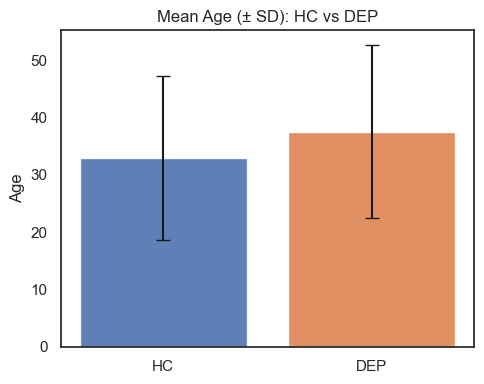

In [7]:
# demographics plots
# age plots
import numpy as np
import matplotlib.pyplot as plt

# Split into groups
age_HC = age[:76]        # subjects 1–76
age_DEP = age[76:]       # subjects 77–2819

# Compute means and standard deviations
means = [np.mean(age_HC), np.mean(age_DEP)]
stds = [np.std(age_HC), np.std(age_DEP)]
groups = ['HC', 'DEP']

# Plot
plt.figure(figsize=(5,4))
plt.bar(groups, means, yerr=stds, capsize=5,
        color=['#4C72B0', '#DD8452'], alpha=0.9)

plt.ylabel('Age')
plt.title('Mean Age (± SD): HC vs DEP')
plt.tight_layout()
plt.show()



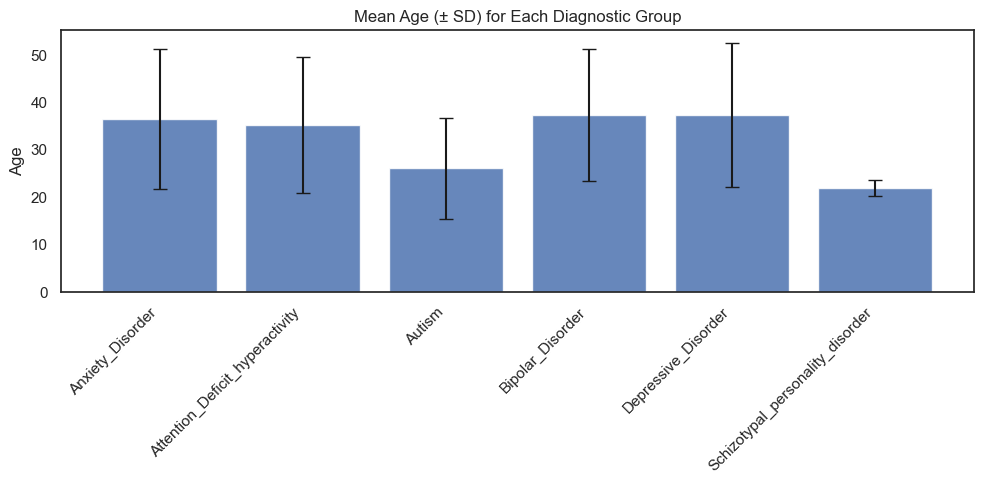

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Diagnostic variables (binary vectors)
diag_vars = {
    'Anxiety_Disorder': Anxiety_Disorder.flatten(),
    'Attention_Deficit_hyperactivity': Attention_Deficit_hyperactivity.flatten(),
    'Autism': Autism.flatten(),
    'Bipolar_Disorder': Bipolar_Disorder.flatten(),
    'Depressive_Disorder': Depressive_Disorder.flatten(),
    'Schizotypal_personality_disorder': Schizotypal_personality_disorder.flatten()
}

# Compute mean and std for each diagnostic group
mean_age = {}
std_age = {}

for name, mask in diag_vars.items():
    group_ages = age[mask == 1]
    mean_age[name] = np.mean(group_ages)
    std_age[name] = np.std(group_ages)

# Prepare for plotting
labels = list(mean_age.keys())
means = list(mean_age.values())
stds = list(std_age.values())

# Plot
plt.figure(figsize=(10, 5))
plt.bar(labels, means, yerr=stds, capsize=5, color='#4C72B0', alpha=0.85)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Age')
plt.title('Mean Age (± SD) for Each Diagnostic Group')

plt.tight_layout()
plt.show()


In [9]:
#run demographics full results and switch working directories to the .csv file path
import pandas as pd
import os
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")
df.info() #quick summary of dataset
df.describe() #stats summary
df.head() #check first few columns
df.isna().sum() #check for NA data
for col in df.columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))
#clean NAs
df_clean = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2743 entries, 0 to 2742
Columns: 1020 entries, CID to Sensory_Distortions
dtypes: float64(835), int64(107), object(78)
memory usage: 21.3+ MB

=== CID ===
CID
1259493.0    1
997061.0     1
1258595.0    1
1611321.0    1
977703.0     1
            ..
693789.0     1
1238325.0    1
1274265.0    1
1222861.0    1
772349.0     1
Name: count, Length: 2743, dtype: int64

=== Location_ID ===
Location_ID
 11    501
 2     295
-1     252
 10    242
 13    229
 12    224
 8     222
 7     212
 4     154
 5     142
 3     103
 6      87
 14     77
 1       3
Name: count, dtype: int64

=== age ===
age
20    111
21     95
19     93
23     91
24     89
     ... 
83      1
8       1
9       1
10      1
86      1
Name: count, Length: 74, dtype: int64

=== sex_coded ===
sex_coded
2    1553
1    1190
Name: count, dtype: int64

=== dx ===
dx
6     547
4     546
5     495
7     383
8     201
3     179
2     155
9     110
10     65
11     30
12     14
13      

In [10]:
#provide info of cleaned dataset
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Columns: 1020 entries, CID to Sensory_Distortions
dtypes: float64(835), int64(107), object(78)
memory usage: 0.0+ bytes


In [12]:
#generate demographics summary
sex_coded = df["sex_coded"].value_counts(dropna=False).to_frame("Count")
sex_coded["Percent"] = (sex_coded["Count"] / len(df) * 100).round(1)
sex_coded
#1 = M; 2 = F


,Count,Percent
sex_coded,,
2,1553,56.6
1,1190,43.4
